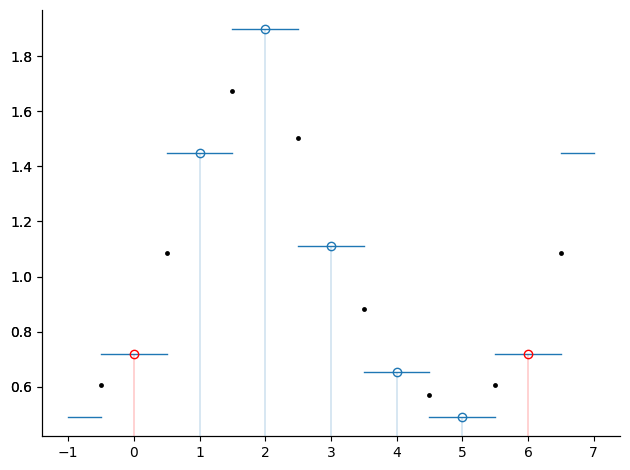

In [4]:
# Load the required libraries
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

import splinekit as sk # This library

# Setup
support = 6
min_degree = 0
max_degree = 10

# Initial spline
s = sk.PeriodicSpline1D.from_spline_coeff(np.random.standard_normal(support), degree = min_degree)

# Display update
out = widgets.Output()
hdisplay = display("", display_id = True)
def plot_spline (
):
    (fig, ax) = plt.subplots()
    s.plot((fig, ax), plotpoints = 301)
    plt.close()
    hdisplay.update(fig)
# plot_spline()

# Allow for the selection of the degree
deg_slider = widgets.IntSlider(min = min_degree, max = max_degree, value = s.degree)
def on_value_change (
    change
):
    global s
    s = s.projected(degree = change["new"])
    plot_spline()
deg_slider.observe(on_value_change, names = "value")

# Stepper
play = widgets.Play(
    value = min_degree,
    min = min_degree,
    max = max_degree,
    step = 1,
    interval = 1000,
    description = "Press play",
    disabled = False,
    repeat = True,
    show_repeat = False
)
widgets.jslink((play, 'value'), (deg_slider, 'value'))
widgets.HBox([play, deg_slider])
